# 11_数据预处理方法-特征选择

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 先保留独立测试集，再进行标准化及监督特征选择；特征集合的比较使用同一个测试集。Lasso 的超参数搜索也在完整预处理 Pipeline 内执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天的文章和大家来聊聊数据与处理方法中的特征选择\~

在开始说特征选择前，咱们先搞清楚“特征”是啥。

打个比方，如果我们要训练一个模型来判断某个人是否会买一双运动鞋，我们可能会收集一些跟这个人有关的信息，比如：

- 年龄
- 性别
- 喜欢运动吗
- 平时穿什么鞋
- 收入多少
- 是否经常网购

这些信息就是“特征”，也可以叫“变量”或“属性”。

简单说，就是用来描述某个对象（在这个例子中是“人”）的一组数据。

### 那什么是特征选择？

**特征选择**，就是从一堆特征中**挑出对结果最有用的那几个**。

比如我们收集了100个特征，但其实可能只有5\~10个是对我们要解决的问题真正有帮助的。其余的特征不仅没用，有时候还会干扰模型判断，让结果更差。

特征选择的目的就像是：

> 我们在菜市场挑菜，要做一道菜，不需要所有的菜，只挑对的、好的、能用上的菜。

### 为什么要做特征选择？

原因很简单，有几个关键点：

1. **减少数据维度**：特征太多会让模型变慢、变复杂，选出关键特征后，模型更快也更好理解。
2. **提高模型性能**：去掉“干扰项”，模型能更专注于真正重要的因素，预测结果可能更准。
3. **防止过拟合**：特征太多可能会让模型“记住”训练数据而不是“学会”规律，选少一些能防止这个问题。
4. **节省资源**：比如数据采集和存储的成本也会降低。

### 特征选择怎么做？

不用展开太复杂，这里简单提几个常见的方法：

- **看相关性**：比如统计每个特征和结果之间的关系，关系弱的就去掉。
- **用模型评估**：让模型自己“评分”哪些特征更有用，选得分高的。
- **一步一步试**：每次加入或去掉一个特征，看模型效果变好还是变差。

总结一句话，特征选择就像是在做减法，我们从一堆数据中挑出对结果最有帮助的那几项，让模型更聪明、更高效、更靠谱。

## 原理详解

特征选择（Feature Selection）本质是**寻找与目标变量（label）关联性强、冗余性低的特征子集**。

其目标可归结为一个优化问题：


$$
\mathcal{S}^* = \arg\max_{\mathcal{S} \subseteq \mathcal{F}} \text{Score}(\mathcal{S})
$$


其中：

- $\mathcal{F}$ 是所有特征的集合，假设有 $d$ 个特征：$\mathcal{F} = \{f_1, f_2, \dots, f_d\}$
- $\mathcal{S}$ 是从 $\mathcal{F}$ 中选择的子集（特征子集）
- $\text{Score}(\mathcal{S})$ 是衡量特征子集“好坏”的评分函数，通常基于互信息、相关系数、模型性能等

特征选择要解决的问题有两个关键点：

1. **相关性（Relevance）**：特征是否对目标变量有信息量
2. **冗余性（Redundancy）**：特征之间是否高度相关、重复

## 数学指标

### 1. 互信息 Mutual Information（MI）

衡量特征 $X$ 与目标 $Y$ 之间的信息量：


$$
I(X; Y) = \sum_{x \in X} \sum_{y \in Y} p(x, y) \log \left( \frac{p(x, y)}{p(x)p(y)} \right)
$$


解释：

- 如果 $X$ 和 $Y$ 完全独立，则 $I(X; Y) = 0$
- 越高表示 $X$ 提供关于 $Y$ 越多的信息，越“相关”

在特征选择中，我们希望选择互信息较大的特征。

### 2. 方差选择法（Variance Threshold）

如果一个特征的方差接近于0，说明这个特征在所有样本中几乎是常量，对分类或回归没有贡献：


$$
\text{Var}(X) = \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^2
$$


我们可以设定一个阈值 $\theta$，选择满足 $\text{Var}(X) > \theta$ 的特征。

### 3. 皮尔逊相关系数（Pearson Correlation）

衡量特征 $X$ 与目标 $Y$ 的线性相关性：


$$
\rho_{X,Y} = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y} = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}}
$$


适合数值型变量，绝对值越大，相关性越强。

### 4. 最小冗余最大相关（mRMR）

这是一个综合相关性与冗余性的方法，目标函数：


$$
\text{Score}(f_i) = I(f_i; y) - \frac{1}{|S|} \sum_{f_j \in S} I(f_i; f_j)
$$


其中：

- 第一项是特征 $f_i$ 和目标 $y$ 的互信息（代表相关性）
- 第二项是 $f_i$ 和已选特征集合 $S$ 的平均互信息（代表冗余性）

我们希望选择得分最大的特征。

### 5. 正则化方法：L1正则（Lasso）

Lasso 是一种模型内嵌特征选择方法，它在损失函数中加入 $L_1$ 范数项：


$$
\min_w \left\{ \frac{1}{2n} \sum_{i=1}^n (y_i - w^T x_i)^2 + \lambda \|w\|_1 \right\}
$$


Lasso 的一个性质是会将部分权重 $w_i = 0$，即对应特征被自动“剔除”，从而实现特征选择。

## 特征选择的算法流程（分类）

### 方法分类

1. **Filter（过滤法）**

   - 不依赖模型，单独评估特征
   - 如：互信息、相关系数、卡方检验、方差过滤
2. **Wrapper（包装法）**

   - 使用模型训练+验证去评估特征子集的性能
   - 如：递归特征消除（RFE）
3. **Embedded（嵌入法）**

   - 模型训练中自动完成选择
   - 如：Lasso、决策树的特征重要性

### Filter 方法流程

以互信息为例：

1. 输入：数据集 $X \in \mathbb{R}^{n \times d}$、目标变量 $y$
2. 对每个特征 $f_i$，计算 $I(f_i; y)$
3. 选择前 $k$ 个互信息最大的特征，或设阈值筛选
4. 输出特征子集

### Wrapper 方法流程（如递归特征消除 RFE）：

1. 输入：数据集 $X$、标签 $y$、学习器模型（如SVM）
2. 用所有特征训练模型
3. 根据模型权重排序特征重要性
4. 删除最不重要的特征（一个或多个）
5. 重复 2\~4 步，直到达到预期特征数
6. 输出特征子集

### Embedded 方法流程（以 Lasso 为例）：

1. 输入：数据集 $X$、标签 $y$、L1正则系数 $\lambda$
2. 用 Lasso 回归拟合数据，最小化损失函数
3. 得到权重向量 $w$，统计哪些特征 $w_i \neq 0$
4. 输出这些非零权重对应的特征子集

## 完整案例

咱们这里的案例包括：

1. 数据加载与预处理
2. 多种特征选择方法应用（Filter、Wrapper、Embedded）
3. 可视化分析
4. 模型性能评估与优化

数据方面，我们以经典的**UCI乳腺癌数据集（Breast Cancer Wisconsin Dataset）**为例，进行实验\~

#### 导入库并加载数据

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

plt.rcParams['font.sans-serif'] = CJK_FONTS
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

#### 数据预览与探索性分析

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11703/1113506002.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


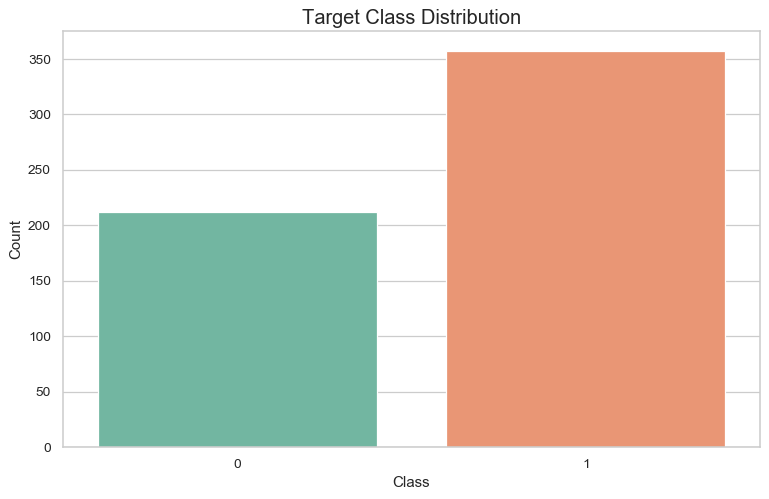

In [3]:
# 读取数据集
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# 基本信息
print(df.info())
print(df.describe())

# 类别分布
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

这是一个二分类问题（0=恶性，1=良性），类分布不平衡不明显，适合用于模型训练。

![原文参考图，当前结果见代码输出](attachments/img_028.png)

#### 特征标准化

In [4]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

部分模型（如逻辑回归、Lasso）对特征量纲敏感，因此需要标准化。

#### Filter法：SelectKBest + 互信息

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11703/3916523890.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df.head(15), x='MI Score', y='Feature', palette='plasma')


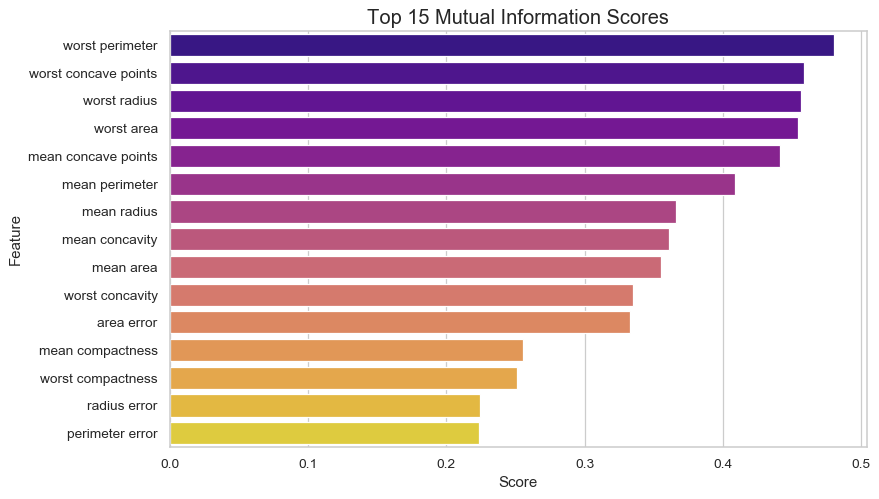

In [5]:
# 选择前10个互信息得分最高的特征
selector_mi = SelectKBest(score_func=mutual_info_classif, k=10)
X_mi = selector_mi.fit_transform(X_scaled, y_train)
selected_features_mi = X.columns[selector_mi.get_support()]

# 可视化互信息得分
mi_scores = selector_mi.scores_
mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values(by='MI Score', ascending=False)

sns.barplot(data=mi_df.head(15), x='MI Score', y='Feature', palette='plasma')
plt.title("Top 15 Mutual Information Scores")
plt.xlabel("Score")
plt.ylabel("Feature")
plt.show()

互信息反映特征与目标变量之间的非线性关系，分数越高，说明该特征包含的“信息量”越大。

![原文参考图，当前结果见代码输出](attachments/img_029.png)

#### Wrapper法：递归特征消除 RFE

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11703/2511863462.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rfe_result, x='Selected', y='Feature', palette='coolwarm')


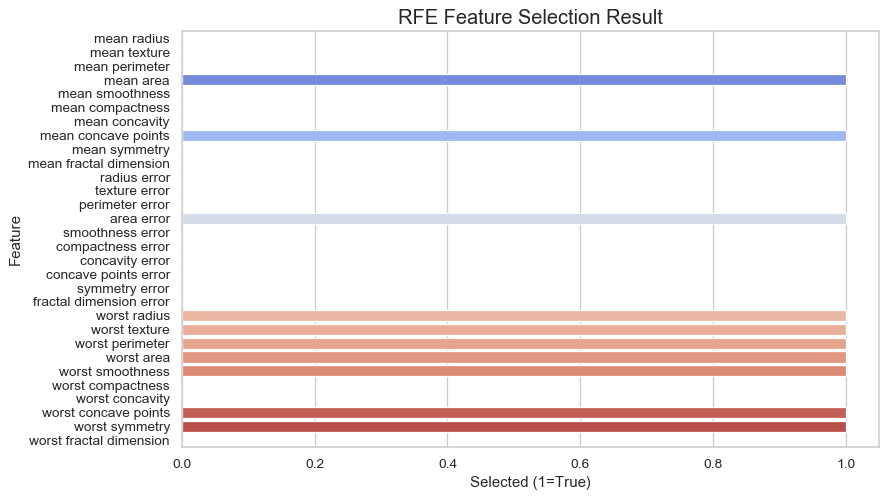

In [6]:
# 用逻辑回归做基模型，递归删除特征
model = LogisticRegression(max_iter=5000)
rfe = RFE(estimator=model, n_features_to_select=10)
X_rfe = rfe.fit_transform(X_scaled, y_train)

selected_features_rfe = X.columns[rfe.support_]

# 可视化选择结果
rfe_result = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_
})
sns.barplot(data=rfe_result, x='Selected', y='Feature', palette='coolwarm')
plt.title("RFE Feature Selection Result")
plt.xlabel("Selected (1=True)")
plt.ylabel("Feature")
plt.show()

Wrapper方法通过“反复试验”直接评估特征对模型性能的影响，适合找组合最优特征子集。

![原文参考图，当前结果见代码输出](attachments/img_030.png)

#### Embedded法：Lasso回归自动选择

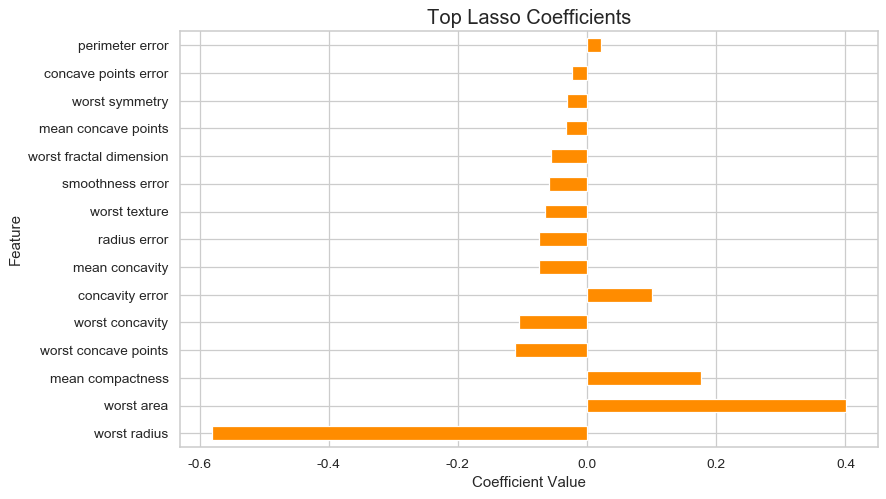

In [7]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
lasso_search = GridSearchCV(make_pipeline(StandardScaler(), Lasso(max_iter=20000)),
                            {'lasso__alpha': np.logspace(-3, -1, 12)},
                            cv=5, scoring='neg_mean_squared_error', error_score='raise')
lasso_search.fit(X_train, y_train)
lasso = lasso_search.best_estimator_.named_steps['lasso']

# Lasso回归系数
lasso_coef = pd.Series(lasso.coef_, index=X.columns)
selected_features_lasso = lasso_coef[lasso_coef != 0].index

# 可视化
lasso_coef_sorted = lasso_coef.sort_values(key=abs, ascending=False).head(15)
lasso_coef_sorted.plot(kind='barh', color='darkorange')
plt.title("Top Lasso Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

Lasso通过惩罚项自动将一些不重要的特征系数压缩为0，实现了模型训练与特征选择同步进行。

![原文参考图，当前结果见代码输出](attachments/img_031.png)

#### 比较不同方法选择的特征

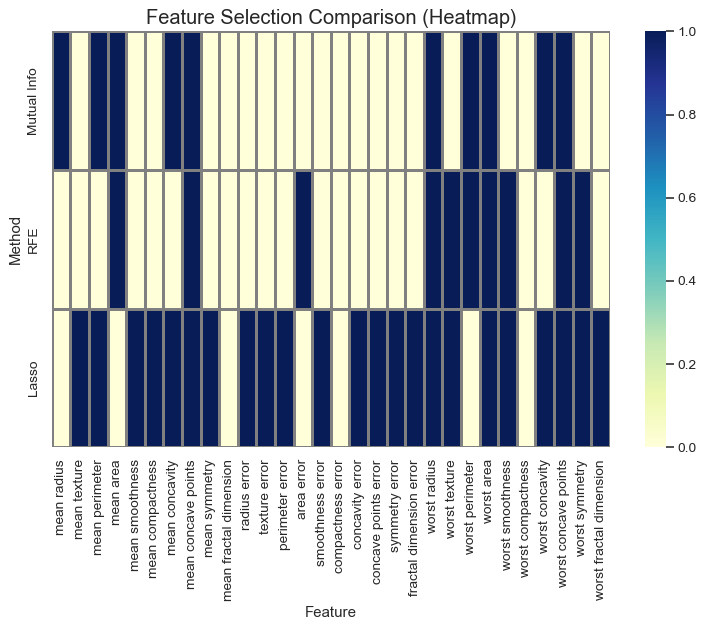

In [8]:
methods = ['Mutual Info', 'RFE', 'Lasso']
sets = [set(selected_features_mi), set(selected_features_rfe), set(selected_features_lasso)]

# 构建特征选择结果的对比图
all_features = list(X.columns)
results_df = pd.DataFrame({'Feature': all_features})

for method, selected in zip(methods, sets):
    results_df[method] = results_df['Feature'].apply(lambda f: 1 if f in selected else 0)

# 可视化为热力图
sns.heatmap(results_df.set_index('Feature').T, cmap='YlGnBu', cbar=True, linewidths=1, linecolor='gray')
plt.title("Feature Selection Comparison (Heatmap)")
plt.xlabel("Feature")
plt.ylabel("Method")
plt.show()

直观对比不同方法所选的特征，发现有些特征是多方法共同选中的，可信度更高。

![原文参考图，当前结果见代码输出](attachments/img_032.png)

#### 模型性能评估（使用随机森林）

In [9]:
# 使用不同特征集合训练模型
feature_sets = {
    'All Features': X.columns,
    'Mutual Info': selected_features_mi,
    'RFE': selected_features_rfe,
    'Lasso': selected_features_lasso
}

for name, features in feature_sets.items():
    columns = [X.columns.get_loc(f) for f in features]
    X_subset_train, X_subset_test = X_scaled[:, columns], X_test_scaled[:, columns]
    
    model = RandomForestClassifier(random_state=42)
    model.fit(X_subset_train, y_train)
    y_pred = model.predict(X_subset_test)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_subset_test)[:, 1])
    
    print(f"【{name}】")
    print(f"Accuracy: {acc:.4f}, AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

【All Features】
Accuracy: 0.9357, AUC: 0.9913
              precision    recall  f1-score   support

           0       0.92      0.91      0.91        64
           1       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171

------------------------------------------------------------
【Mutual Info】
Accuracy: 0.9298, AUC: 0.9858
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        64
           1       0.93      0.96      0.94       107

    accuracy                           0.93       171
   macro avg       0.93      0.92      0.92       171
weighted avg       0.93      0.93      0.93       171

------------------------------------------------------------
【RFE】
Accuracy: 0.9532, AUC: 0.9922
              precision    recall  f1-score   support

           0       0.97      0.91      0.94 

在减少特征数量的同时，我们观察模型的准确率和AUC指标是否下降，如果保持稳定或更好，说明特征选择有效。

#### 算法优化建议

- 使用**集成选择策略**，比如只选择多个方法共同提取的特征，提高鲁棒性
- 对特征选择过程加上交叉验证，避免过拟合
- 尝试增加更多非线性方法（如XGBoost）进行嵌入式特征选择
- 应用PCA（主成分分析）进行降维后比较性能

## 模型分析

### 各个特征选择方法的优缺点

我们在案例中使用了三种常见的特征选择方法：

- Filter（过滤法）：以互信息为代表
- Wrapper（包装法）：以递归特征消除 RFE 为代表
- Embedded（嵌入法）：以 Lasso 回归为代表

下面从多个角度分析这三种方法在实际案例中的**综合优缺点**：

#### 优点分析

- **通用性强**：三种方法基本覆盖了大多数特征选择需求，适用于分类问题中的各种模型结构（线性/非线性均可）。
- **解释性好**：每种方法都有明确的数学解释，例如互信息反映变量之间的非线性信息量、Lasso通过系数稀疏性体现特征重要性，方便特征意义理解。
- **降低维度风险**：通过删除低信息量或冗余的特征，不仅减少了模型训练的计算负担，同时降低了模型的过拟合风险。
- **可组合优化**：在案例中我们展示了多方法交叉选择特征的手段，这种“集成特征选择”思路在实战中非常实用，稳定性好。

#### 缺点分析

- **方法局限性明显**：

  - Filter法没有考虑特征之间的交互关系，可能会保留冗余特征。
  - Wrapper法计算成本高，尤其在特征维度很大时效率低下。
  - Embedded方法（如Lasso）适用于线性模型，对于复杂非线性关系（如图像、NLP任务）效果会下降。
- **对数据类型敏感**：如互信息对于连续型变量需要离散化处理，否则评分不准；RFE对模型初选非常敏感；Lasso只适用于数值型特征。
- **特征子集不稳定**：在数据轻微变化时，Wrapper 和 Lasso 的选中特征可能不同，影响模型一致性。
- **依赖模型假设**：Lasso 假设特征与目标之间存在线性关系；如果真实关系是非线性的，则选择结果偏差较大。

### 与相似算法的对比

| 方法类别 | 算法 | 是否考虑特征间关系 | 是否依赖模型 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|-|-|-|
| Filter | 互信息（MI） | 否 | 否 | 计算快，不依赖模型，可解释性好 | 忽略特征间冗余性 | 快速预筛选，特征数较大时 |
| Filter | 卡方检验 / F检验 | 否 | 否 | 适用于离散变量，解释性强 | 不支持连续目标，变量需离散化 | 分类任务中特征初选 |
| Wrapper | RFE | 是 | 是 | 考虑特征组合效果，模型驱动 | 训练耗时长，过拟合风险高 | 特征少、关注性能优先时 |
| Embedded | Lasso | 否（部分） | 是 | 自动降维，嵌入模型中，效率高 | 线性模型假设，不适用于非线性任务 | 高维稀疏数据，线性回归场景 |
| Embedded | 决策树/随机森林重要性 | 是 | 是 | 适用于非线性，解释力强 | 可能对噪声敏感，重要性易变 | 非线性任务、结构化数据分析 |
| 降维方法（替代） | PCA（主成分分析） | 是（转换维度） | 否 | 无监督降维，消除多重共线性 | 不保留原始语义，解释性差 | 高维连续数据、可视化探索性分析 |
| 特征学习方法 | AutoEncoder / 深度网络 | 是（非线性） | 是 | 能处理复杂特征交互，高表达力 | 训练复杂，可解释性差 | 图像、语音、文本类非结构化任务 |

### 在什么情况下优选该类特征选择算法

#### 应优先使用该类算法的场景

1. **结构化数据**：如医疗、金融、电商等传统结构化数据集，有清晰的变量意义。
2. **中小特征集**：特征在几十到几百维时，使用上述方法效率高、效果好。
3. **模型可解释性要求高**：比如医疗诊断、信用评估等，需要解释“为什么选择这些变量”。
4. **需要模型精简部署**：在嵌入式或边缘设备部署场景下，需要减少特征数量。
5. **早期探索性数据分析**：用于快速筛选可疑变量，指导后续建模流程。

### 考虑其他算法的场景

**应考虑替代算法的情况包括：**

1. **特征维度极高**（>10,000）：如文本TF-IDF特征，此时Lasso会收敛困难，RFE计算不可接受，建议用PCA或稀疏模型。
2. **特征间存在复杂非线性关系**：如图像或语音识别任务，此时应考虑用深度学习（如AutoEncoder）进行端到端特征学习。
3. **特征含义不明确或冗余很强**：如基因表达数据，应考虑用聚类或降维技术先压缩信息量。
4. **训练时间极为敏感**：如大数据平台上线任务，应选择快速的Filter方法或预训练方式。
5. **模型不具备稀疏性优势**：如基于集成的XGBoost等模型本身有特征筛选机制，不需要再手动选择。

## 总结

特征选择作为数据与处理方法中极为重要的一环，在模型性能提升、解释性增强、计算资源优化等方面都有不可替代的作用。本文通过具体案例演示了互信息、RFE 和 Lasso 三种方法的实际应用，辅以强视觉化手段，清晰展示了模型对特征的依赖程度。

然而，正如表格所述，每种方法都有局限性，在具体项目中应结合数据类型、模型结构、任务目标、部署环境等多重因素综合选择。没有“万能”的特征选择方法，只有最适合场景的策略。